# EDA

# https://www.kaggle.com/datasets/chizhikchi/andalusian-hotels-reviews-unbalanced?select=Big_AHR.csv
# https://huggingface.co/datasets/Karpacious/hotel-reviews-es

Creditos Dataset: Karpacious https://huggingface.co/Karpacious



## Configuración del entorno

**Objetivo:** preparar librerías (`pandas`, `numpy`, `matplotlib`, `seaborn`), rutas a los datos y estilo de gráficos para todo el notebook. Lista los CSV disponibles en la carpeta de datos.

In [1]:
# Configuración y librerías
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from collections import Counter

# Estilo y tamaño de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# Ruta de la carpeta con los datos
CARPETA_DATOS = Path(r"../data")
archivos = list(CARPETA_DATOS.glob("*.csv"))
print("Archivos CSV encontrados:", [f.name for f in archivos])

Archivos CSV encontrados: ['Balanced_AHR.csv', 'Big_AHR.csv', 'dataset_hoteles_es_final_UTF8BOM.csv', 'resenas_hotel.csv']


## 1. Carga de datos

Los CSV usan **punto y coma (,)** como separador.

## Carga inicial de los tres datasets

**Objetivo:** leer `Big_AHR`, `Balanced_AHR` y `dataset_hoteles_es` e imprimir dimensiones para conocer el tamaño de cada fuente antes del análisis.

In [2]:
df_Big_AHR = pd.read_csv(CARPETA_DATOS / "Big_AHR.csv", sep=",", encoding="utf-8")
df_Balanced_AHR = pd.read_csv(CARPETA_DATOS / "Balanced_AHR.csv", sep=",", encoding="utf-8")
df_hoteles_es = pd.read_csv(CARPETA_DATOS / "dataset_hoteles_es_final_UTF8BOM.csv", sep=",", encoding="utf-8")

print("=== BIG AHR ===")
print(f"Dimensiones: {df_Big_AHR.shape[0]} filas, {df_Big_AHR.shape[1]} columnas")
print("\n=== BALANCED AHR ===")
print(f"Dimensiones: {df_Balanced_AHR.shape[0]} filas, {df_Balanced_AHR.shape[1]} columnas")
print("\n=== HOTELES ES ===")
print(f"Dimensiones: {df_hoteles_es.shape[0]} filas, {df_hoteles_es.shape[1]} columnas")

=== BIG AHR ===
Dimensiones: 18172 filas, 7 columnas

=== BALANCED AHR ===
Dimensiones: 7615 filas, 7 columnas

=== HOTELES ES ===
Dimensiones: 750 filas, 6 columnas


### Tenemos 3 datasets de los cuales vamos a usar el dataset de Big_AHR y el de hoteles_es para hacer un EDA el objetivo es generar un dataset balanceado para entrenar un modelo de clasificación de sentimientos.


## 2. EDA

### Estructura de Big_AHR

**Objetivo:** inspeccionar tipos de columnas, memoria y una muestra de filas del dataset grande (no balanceado).

In [3]:
# Info y tipos
df_Big_AHR.info()
df_Big_AHR.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18172 entries, 0 to 18171
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   18172 non-null  int64 
 1   title        18172 non-null  object
 2   rating       18172 non-null  int64 
 3   review_text  18172 non-null  object
 4   location     16356 non-null  object
 5   hotel        16356 non-null  object
 6   label        18172 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 993.9+ KB


,Unnamed: 0,title,rating,review_text,location,hotel,label
0,0,Excelente y personal amable,5,Un hotel muy bueno. El personal fue muy amabl...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
1,1,Céntrico,4,"Muy buen hotel al nivel de lo esperado, habita...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
2,2,Hotel excepcional,5,Magnífico hotel. La verdad es que todo perfect...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
3,3,WOW!!,5,"Hotel hermoso, buen diseño, original, limpio. ...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
4,4,Magnifico,5,Magnífica ubicación en pleno centro de Sevilla...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
5,5,Mejor hotel de ciudad en Sevilla,5,Si estás buscando un hotel para alojarte en el...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
6,6,Ubicación y comodidad,4,Gran ubicación y una enorme comodidad. La cama...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
7,7,Muy buena relación calidad-precio,5,"Precioso hotel en pleno centro de Sevilla, ent...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
8,8,Lo mejor su personal,5,"Como todos los hoteles de la cadena, un 10. Ha...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
9,9,HOTEL PRECIOSO,5,Empiezo por lo menos agradable: no es posible ...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1


### Estructura de hoteles_es

**Objetivo:** revisar `info()` y primeras filas del CSV de reseñas en español para validar columnas y calidad básica.

In [4]:
df_hoteles_es.info()   
df_hoteles_es.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hotel        750 non-null    object 
 1   ciudad       750 non-null    object 
 2   fecha        750 non-null    object 
 3   texto        750 non-null    object 
 4   rating       750 non-null    float64
 5   sentimiento  750 non-null    object 
dtypes: float64(1), object(5)
memory usage: 35.3+ KB


,hotel,ciudad,fecha,texto,rating,sentimiento
0,Vista Real,Madrid,2023-03-05,El baño estaba sucio al llegar.,4.7,negativo
1,Luna Park,San Sebastián,2023-10-20,Demasiado ruido durante la noche.,4.0,negativo
2,Brisa Marina,Bilbao,2023-04-02,Desayuno espectacular y personal muy atento.,8.6,positivo
3,Bahía Palace,San Sebastián,2023-04-26,Falta de mantenimiento en las instalaciones.,5.4,negativo
4,Oasis Beach,Granada,2023-01-09,Muy buena ubicación y excelente limpieza.,9.0,positivo
5,Costa Mar,Salamanca,2023-08-24,Muy buena ubicación y excelente limpieza.,7.6,positivo
6,Costa Mar,Málaga,2023-12-25,Personal poco atento y recepción caótica.,5.1,negativo
7,Brisa Marina,Granada,2023-09-23,Falta de mantenimiento en las instalaciones.,4.8,negativo
8,Mar y Montaña,Sevilla,2023-05-21,Servicio amable. Volvería sin dudarlo.,9.3,positivo
9,Bahía Palace,San Sebastián,2023-09-13,Demasiado ruido durante la noche.,5.8,negativo


### El objetivo es tener un unico dataset, se va a usar la review y el sentimiento por el momento omitimos los ratings y demas columnas, de df_hoteles_es usamos la columna (texto, sentimiento) y de  df_Big_AHR (review_text, label)

## Unificación de reseñas (Big_AHR + hoteles_es)

**Objetivo:** homogeneizar nombres a `review` y `sentimiento`, mapear etiquetas numéricas de Big_AHR a texto y concatenar ambas fuentes en un solo `DataFrame` `df_resenas` para el EDA global.

In [5]:
# Dataset unificado: columnas review y sentimiento
# df_Big_AHR: review_text, label  |  df_hoteles_es: texto, sentimiento
df_resenas_ahr = df_Big_AHR.rename(columns={
    "review_text": "review",
    "label": "sentimiento",
})[["review", "sentimiento"]]

# En Big_AHR, label es 0/1; alinear con las etiquetas en texto de hoteles_es
df_resenas_ahr["sentimiento"] = df_resenas_ahr["sentimiento"].map({1: "positivo", 0: "negativo", 3: "neutro"})

df_resenas_es = df_hoteles_es.rename(columns={"texto": "review"})[["review", "sentimiento"]]

df_resenas = pd.concat([df_resenas_ahr, df_resenas_es], ignore_index=True)

print("Dataset unificado de reseñas:", df_resenas.shape)
display(df_resenas.head())


Dataset unificado de reseñas: (18922, 2)


,review,sentimiento
0,Un hotel muy bueno. El personal fue muy amabl...,positivo
1,"Muy buen hotel al nivel de lo esperado, habita...",positivo
2,Magnífico hotel. La verdad es que todo perfect...,positivo
3,"Hotel hermoso, buen diseño, original, limpio. ...",positivo
4,Magnífica ubicación en pleno centro de Sevilla...,positivo


### Codificación numérica del sentimiento

**Objetivo:** convertir etiquetas de texto (`positivo`, `negativo`, `neutro`) a valores numéricos (1, 0, 3) de forma consistente para gráficos y modelos.

In [6]:
# Convertimos los valores de sentimiento: positivo = 1, negativo = 0
df_resenas["sentimiento"] = df_resenas["sentimiento"].map({"positivo": 1, "negativo": 0, "neutro": 3})



### Vista del dataset unificado

**Objetivo:** mostrar el `DataFrame` completo o su representación para comprobar el resultado de la unión y las columnas finales.

In [7]:
# Mostrar el DataFrame `df_resenas` completo para validar la unión de fuentes.
df_resenas

,review,sentimiento
0,Un hotel muy bueno. El personal fue muy amabl...,1
1,"Muy buen hotel al nivel de lo esperado, habita...",1
2,Magnífico hotel. La verdad es que todo perfect...,1
3,"Hotel hermoso, buen diseño, original, limpio. ...",1
4,Magnífica ubicación en pleno centro de Sevilla...,1
...,...,...
18917,Demasiado ruido durante la noche.,0
18918,Muy buena ubicación y excelente limpieza.,1
18919,Muy buena ubicación y excelente limpieza.,1
18920,El baño estaba sucio al llegar.,0


### Distribución de clases (dataset no balanceado)

**Objetivo:** cuantificar y visualizar la proporción Negativo / Neutro / Positivo en `df_resenas` con barras y pastel, detectando desbalance entre clases.

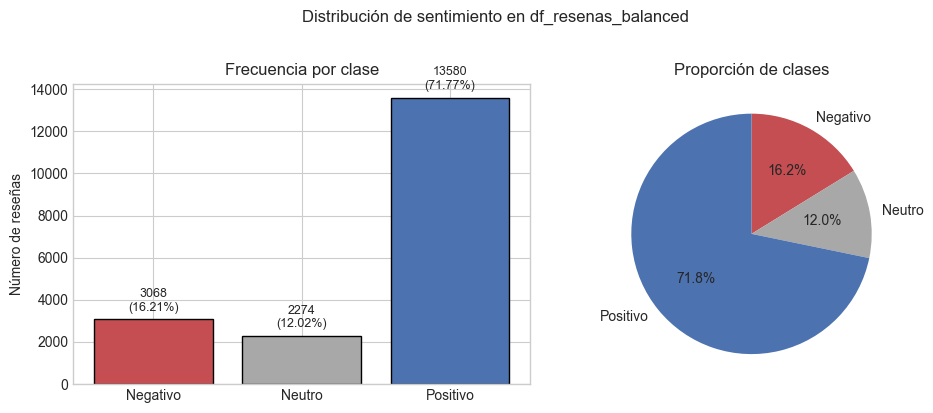

,clase,n,pct
0,Negativo,3068,16.21
1,Neutro,2274,12.02
2,Positivo,13580,71.77


In [8]:
# Distribución de clases: negativo / neutro / positivo (texto o etiquetas 0, 1, 3)
def _etiqueta_sentimiento(v):
    if pd.isna(v):
        return "NaN"
    if isinstance(v, (int, float)) and not isinstance(v, bool):
        if v in (0, 0.0):
            return "Negativo"
        if v in (1, 1.0):
            return "Positivo"
        if v in (3, 3.0):
            return "Neutro"
    s = str(v).strip().lower()
    if s in ("negativo", "0"):
        return "Negativo"
    if s in ("positivo", "1"):
        return "Positivo"
    if s in ("neutro", "3"):
        return "Neutro"
    return str(v).title()

orden_clases = ["Negativo", "Neutro", "Positivo"]
colores_clase = {"Negativo": "#c44e52", "Neutro": "#a8a8a8", "Positivo": "#4c72b0"}

serie = df_resenas["sentimiento"].map(_etiqueta_sentimiento)
counts = serie.value_counts()
orden = [c for c in orden_clases if c in counts.index]
otros = [c for c in counts.index if c not in orden_clases]
counts = counts.reindex(orden + sorted(otros))
pct = (counts / len(df_resenas) * 100).round(2)
etiquetas = list(counts.index)
colors = [colores_clase.get(c, "#888888") for c in etiquetas]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(etiquetas, counts.values, color=colors, edgecolor="black")
axes[0].set_title("Frecuencia por clase")
axes[0].set_ylabel("Número de reseñas")
ymax = counts.values.max()
for i, (v, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, v + ymax * 0.02, f"{int(v)}\n({p}%)", ha="center", fontsize=9, va="bottom")

axes[1].pie(
    counts.values,
    labels=etiquetas,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    counterclock=False,
)
axes[1].set_title("Proporción de clases")
plt.suptitle("Distribución de sentimiento en df_resenas_balanced", y=1.02)
plt.tight_layout()
plt.show()

display(pd.DataFrame({"clase": etiquetas, "n": counts.values, "pct": pct.values}))

## Usar el dataset completo no parece ser la mejor decision, hay muchos datos de la clase postivia, esto pueden meter muchos sesgo al modelo vamos a revisar el dataset mas pequeño pero balanceado

### Estructura de Balanced_AHR

**Objetivo:** inspeccionar el dataset balanceado de Kaggle antes de mezclarlo con hoteles_es.

In [9]:
# Info y tipos
df_Balanced_AHR.info()
df_Balanced_AHR.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7615 entries, 0 to 7614
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   7615 non-null   int64 
 1   title        7615 non-null   object
 2   rating       7615 non-null   int64 
 3   review_text  7615 non-null   object
 4   location     6819 non-null   object
 5   hotel        6819 non-null   object
 6   label        7615 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 416.6+ KB


,Unnamed: 0,title,rating,review_text,location,hotel,label
0,0,IMPOSIBLE DESCANSAR,2,El fin de semana mi pareja y yo hicimos una re...,Seville_Province_of_Seville_Andalucia,Hotel_Rey_Alfonso_X,0
1,1,No es oro todo lo que reluce,3,"El hotel en general está bien, las habtiacione...",Seville_Province_of_Seville_Andalucia,Hotel_Rey_Alfonso_X,3
2,2,Un buen hotel con mucho ruido.,3,"El hotel es moderno, amplio y limpio, pero no ...",Seville_Province_of_Seville_Andalucia,Hotel_Rey_Alfonso_X,3
3,3,SIN CALEFACCIÓN OPERATIVA Y CON FRÍO,2,Calefacción averiada o no operativa. Se coment...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0
4,4,Deja bastante que desear.,2,Este hotel ha bajado notoriamente su categoria...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0
5,5,Desastre de ascensores,2,"Son pequeños, se bloquean y son insuficientes ...",Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0
6,6,Mal mal y mal,2,Mal mal y mal. Una enorme diferencia de trato ...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0
7,7,Suciedad intolerable,1,Jamás me he encontrado un nivel de suciedad co...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0
8,8,Lamentable,1,Lamentable elegir un hotel de cuatro estrellas...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0
9,9,Sigo aquí pero quiero cambiarme de hotel,2,El hotel fantástico. Los desayunos muy buenos...,Seville_Province_of_Seville_Andalucia,Hotel_Sevilla_Center,0


## Dataset unificado balanceado

**Objetivo:** construir `df_resenas_balanced` uniendo `Balanced_AHR` y `hoteles_es`, añadiendo la columna `fuente` para distinguir el origen de cada reseña.

In [10]:
# Dataset unificado: columnas review y sentimiento
# df_Balanced_AHR: review_text, label  |  df_hoteles_es: texto, sentimiento
df_resenas_ahr_balanced = df_Balanced_AHR.rename(columns={
    "review_text": "review",
    "label": "sentimiento",
})[["review", "sentimiento"]]

# En df_Balanced_AHR, label es 0/1; alinear con las etiquetas en texto de hoteles_es
df_resenas_ahr_balanced["sentimiento"] = df_resenas_ahr_balanced["sentimiento"].map({1: "positivo", 0: "negativo", 3: "neutro"})

df_resenas_ahr_balanced["fuente"] = "Balanced_AHR"

df_resenas_balanced_es = df_hoteles_es.rename(columns={"texto": "review"})[["review", "sentimiento"]]
df_resenas_balanced_es["fuente"] = "hoteles_es"

df_resenas_balanced = pd.concat([df_resenas_ahr_balanced, df_resenas_balanced_es], ignore_index=True)

print("Dataset unificado de reseñas:", df_resenas_balanced.shape)
display(df_resenas_balanced.head())


Dataset unificado de reseñas: (8365, 3)


,review,sentimiento,fuente
0,El fin de semana mi pareja y yo hicimos una re...,negativo,Balanced_AHR
1,"El hotel en general está bien, las habtiacione...",neutro,Balanced_AHR
2,"El hotel es moderno, amplio y limpio, pero no ...",neutro,Balanced_AHR
3,Calefacción averiada o no operativa. Se coment...,negativo,Balanced_AHR
4,Este hotel ha bajado notoriamente su categoria...,negativo,Balanced_AHR


### Distribución de clases (dataset balanceado)

**Objetivo:** repetir el análisis de frecuencias y proporciones sobre `df_resenas_balanced` y comparar visualmente con el conjunto no balanceado.

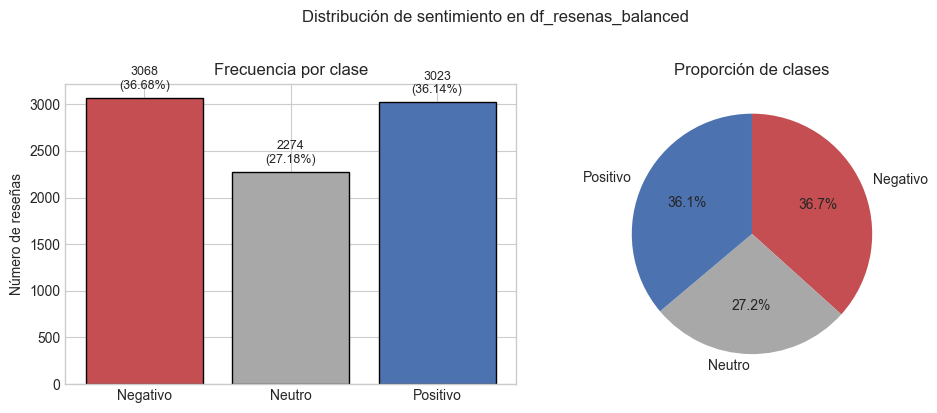

,clase,n,pct
0,Negativo,3068,36.68
1,Neutro,2274,27.18
2,Positivo,3023,36.14


In [11]:
# Distribución de clases: negativo / neutro / positivo (texto o etiquetas 0, 1, 3)
def _etiqueta_sentimiento(v):
    if pd.isna(v):
        return "NaN"
    if isinstance(v, (int, float)) and not isinstance(v, bool):
        if v in (0, 0.0):
            return "Negativo"
        if v in (1, 1.0):
            return "Positivo"
        if v in (3, 3.0):
            return "Neutro"
    s = str(v).strip().lower()
    if s in ("negativo", "0"):
        return "Negativo"
    if s in ("positivo", "1"):
        return "Positivo"
    if s in ("neutro", "3"):
        return "Neutro"
    return str(v).title()

orden_clases = ["Negativo", "Neutro", "Positivo"]
colores_clase = {"Negativo": "#c44e52", "Neutro": "#a8a8a8", "Positivo": "#4c72b0"}

serie = df_resenas_balanced["sentimiento"].map(_etiqueta_sentimiento)
counts = serie.value_counts()
orden = [c for c in orden_clases if c in counts.index]
otros = [c for c in counts.index if c not in orden_clases]
counts = counts.reindex(orden + sorted(otros))
pct = (counts / len(df_resenas_balanced) * 100).round(2)
etiquetas = list(counts.index)
colors = [colores_clase.get(c, "#888888") for c in etiquetas]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(etiquetas, counts.values, color=colors, edgecolor="black")
axes[0].set_title("Frecuencia por clase")
axes[0].set_ylabel("Número de reseñas")
ymax = counts.values.max()
for i, (v, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, v + ymax * 0.02, f"{int(v)}\n({p}%)", ha="center", fontsize=9, va="bottom")

axes[1].pie(
    counts.values,
    labels=etiquetas,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    counterclock=False,
)
axes[1].set_title("Proporción de clases")
plt.suptitle("Distribución de sentimiento en df_resenas_balanced", y=1.02)
plt.tight_layout()
plt.show()

display(pd.DataFrame({"clase": etiquetas, "n": counts.values, "pct": pct.values}))

### Valores faltantes

**Objetivo:** localizar columnas con NaN en el dataset balanceado y medir su impacto en porcentaje sobre el total de filas.

In [12]:
# Valores faltantes
missing_resenas = df_resenas_balanced.isnull().sum()
missing_resenas = missing_resenas[missing_resenas > 0].sort_values(ascending=False)
if len(missing_resenas) > 0:
    print("Valores faltantes (reseñas):")
    display(pd.DataFrame({"missing": missing_resenas, "pct": (missing_resenas / len(df_resenas_balanced) * 100).round(2)}))
else:
    print("No hay valores faltantes en el dataset de reseñas.")

No hay valores faltantes en el dataset de reseñas.


### Longitud de texto por clase (NLP)

**Objetivo:** crear `df_nlp` con `clase` y `len_review`, y resumir estadísticamente la longitud en caracteres por sentimiento (media, mediana, min, max) y globalmente.

In [13]:
# Longitud de caracteres en `review` por etiqueta de sentimiento (3 clases)
def _etiqueta_sentimiento(v):
    if pd.isna(v):
        return "NaN"
    if isinstance(v, (int, float)) and not isinstance(v, bool):
        if v in (0, 0.0):
            return "Negativo"
        if v in (1, 1.0):
            return "Positivo"
        if v in (3, 3.0):
            return "Neutro"
    s = str(v).strip().lower()
    if s in ("negativo", "0"):
        return "Negativo"
    if s in ("positivo", "1"):
        return "Positivo"
    if s in ("neutro", "3"):
        return "Neutro"
    return str(v).title()

df_nlp = df_resenas_balanced.assign(
    clase=df_resenas_balanced["sentimiento"].map(_etiqueta_sentimiento),
    len_review=df_resenas_balanced["review"].fillna("").str.len(),
)
stats = (
    df_nlp.groupby("clase", observed=False)["len_review"]
    .agg(n="count", media="mean", mediana="median", min="min", max="max")
    .round(2)
)
orden = ["Negativo", "Neutro", "Positivo", "NaN"]
stats = stats.reindex([c for c in orden if c in stats.index] + [c for c in stats.index if c not in orden])

display(stats)

tot = df_resenas_balanced["review"].fillna("").str.len()
print(
    f"Todas las reseñas (global): n={len(tot)}, media={tot.mean():.0f}, mediana={tot.median():.0f}, "
    f"min={tot.min()}, max={tot.max()}"
)

,n,media,mediana,min,max
clase,,,,,
Negativo,3068,555.58,479.5,31,5181
Neutro,2274,508.78,428.5,64,7778
Positivo,3023,318.28,265.0,34,1010


Todas las reseñas (global): n=8365, media=457, mediana=354, min=31, max=7778


### Histograma global de longitud de reseñas

**Objetivo:** ver la forma de la distribución de longitudes (caracteres) de todas las reseñas en el conjunto balanceado.

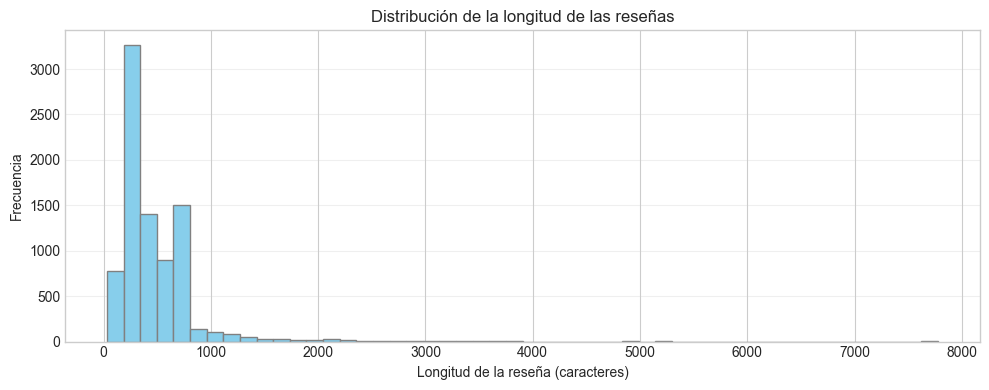

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(df_resenas_balanced["review"].fillna("").str.len(), bins=50, color="skyblue", edgecolor="gray")
plt.title("Distribución de la longitud de las reseñas")
plt.xlabel("Longitud de la reseña (caracteres)")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Boxplot de longitud por sentimiento

**Objetivo:** comparar dispersión y valores atípicos de la longitud del texto entre Negativo, Neutro y Positivo.

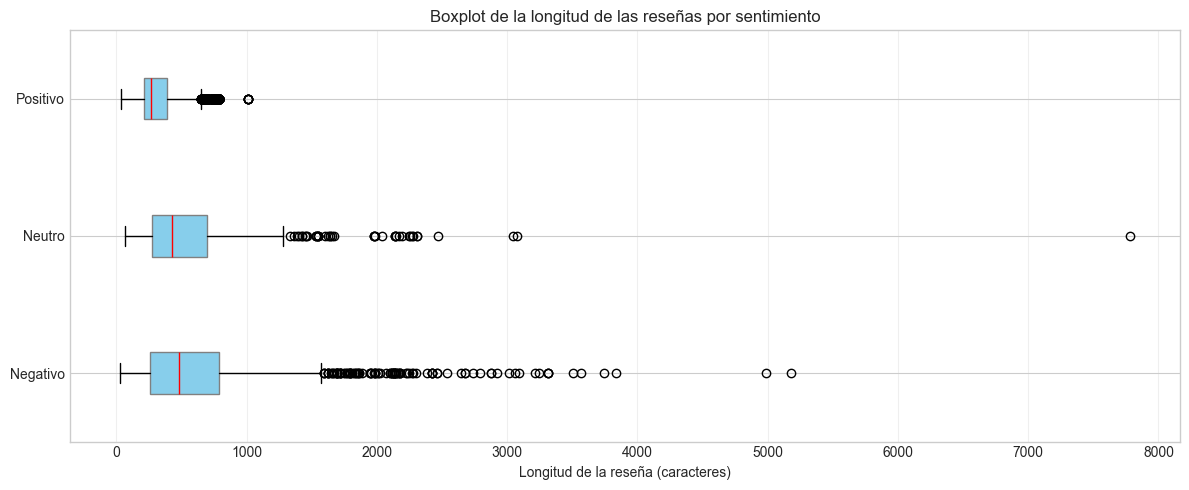

In [15]:
# Graficamos los outliers por sentimiento
plt.figure(figsize=(12, 5))
df_plot = df_nlp[df_nlp["clase"].notnull()]  # Excluye NaN para que el boxplot sea más claro
clases = df_plot["clase"].unique()
clases_orden = [c for c in ["Negativo", "Neutro", "Positivo", "NaN"] if c in clases] + [c for c in clases if c not in ["Negativo", "Neutro", "Positivo", "NaN"]]
data = [df_plot[df_plot["clase"] == c]["len_review"] for c in clases_orden]

plt.boxplot(data, vert=False, patch_artist=True,
            tick_labels=clases_orden,
            boxprops=dict(facecolor="skyblue", color="gray"),
            medianprops=dict(color="red"))
plt.title("Boxplot de la longitud de las reseñas por sentimiento")
plt.xlabel("Longitud de la reseña (caracteres)")
plt.yticks(range(1, len(clases_orden)+1), clases_orden)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### EDA adicional: longitud, duplicados, fuentes y términos frecuentes

Requiere haber ejecutado las celdas que definen `df_resenas_balanced`, `_etiqueta_sentimiento` y `df_nlp`.

### EDA adicional: densidad y forma por clase

**Objetivo:** superponer histogramas de longitud por clase (densidad) y usar un gráfico tipo violin para comparar distribuciones de `len_review`.

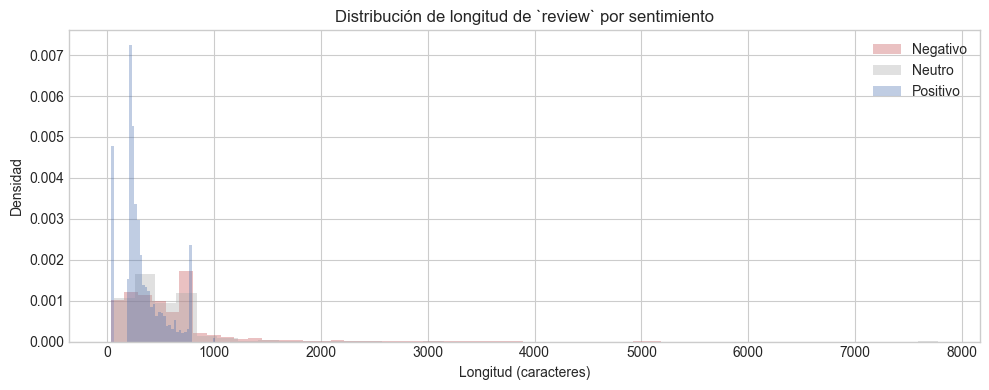

C:\Users\rchic\AppData\Local\Temp\ipykernel_12856\3700806333.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="clase", y="len_review", order=present, palette=[colores_eda[c] for c in present], ax=ax)


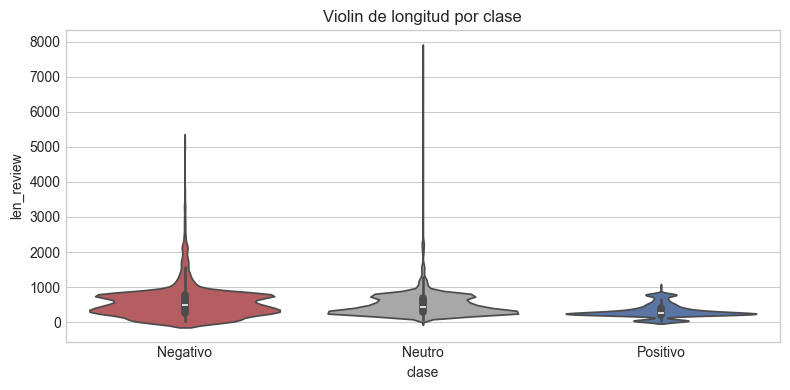

In [16]:
# Histogramas de longitud superpuestos + violin por clase
orden_kw = ["Negativo", "Neutro", "Positivo"]
colores_eda = {"Negativo": "#c44e52", "Neutro": "#a8a8a8", "Positivo": "#4c72b0"}

fig, ax = plt.subplots(figsize=(10, 4))
for c in orden_kw:
    sub = df_nlp[df_nlp["clase"] == c]["len_review"]
    if len(sub) == 0:
        continue
    ax.hist(sub, bins=40, alpha=0.35, label=c, color=colores_eda.get(c, "#888"), density=True)
ax.set_xlabel("Longitud (caracteres)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de longitud de `review` por sentimiento")
ax.legend()
plt.tight_layout()
plt.show()

plot_df = df_nlp[df_nlp["clase"].isin(orden_kw)].copy()
present = [c for c in orden_kw if c in plot_df["clase"].unique()]
fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(data=plot_df, x="clase", y="len_review", order=present, palette=[colores_eda[c] for c in present], ax=ax)
ax.set_title("Violin de longitud por clase")
plt.tight_layout()
plt.show()

### Duplicados de texto en `df_nlp`

**Objetivo:** detectar reseñas repetidas (mismo `review`) y mostrar ejemplos si existen.

In [17]:
# Verificamos si hay reseñas duplicadas
duplicados = df_nlp.duplicated(subset="review", keep=False)
num_duplicados = duplicados.sum()
print(f"Número de reseñas duplicadas: {num_duplicados}")

if num_duplicados > 0:
    print("Ejemplo(s) de reseñas duplicadas:")
    display(df_nlp[duplicados].sort_values("review").head(10))
else:
    print("No se encontraron reseñas duplicadas.")

Número de reseñas duplicadas: 5350
Ejemplo(s) de reseñas duplicadas:


,review,sentimiento,fuente,clase,len_review
1178,"1er point positif ,accueil chaleureux de Javi...",negativo,Balanced_AHR,Negativo,672
1180,"1er point positif ,accueil chaleureux de Javi...",negativo,Balanced_AHR,Negativo,672
1176,"1er point positif ,accueil chaleureux de Javi...",negativo,Balanced_AHR,Negativo,672
2904,"Dormí 2 noches, la habitación limpia y amplia...",neutro,Balanced_AHR,Neutro,212
3030,"Dormí 2 noches, la habitación limpia y amplia...",neutro,Balanced_AHR,Neutro,212
5315,personal muy amable y muy céntrico.La cituaci...,positivo,Balanced_AHR,Positivo,244
6650,personal muy amable y muy céntrico.La cituaci...,positivo,Balanced_AHR,Positivo,244
2859,... pero no tienen ningún tipo de servicio ni ...,neutro,Balanced_AHR,Neutro,789
2505,... pero no tienen ningún tipo de servicio ni ...,neutro,Balanced_AHR,Neutro,789
3410,"0% recomendable, razones aquí: 1. Allanamient...",negativo,Balanced_AHR,Negativo,978


### Conteo de reseñas únicas

**Objetivo:** obtener el número de textos distintos (`nunique`) en la columna `review` respecto al total de filas.

In [18]:
# Contar cuántas reseñas únicas hay en `df_nlp` (texto distinto).
num_unicos = df_nlp["review"].nunique()
print(f"Número de reseñas únicas: {num_unicos}")

Número de reseñas únicas: 5111


### DataFrame único y distribución por clase

**Objetivo:** eliminar duplicados por `review` generando `df_unicos` y graficar de nuevo la distribución de clases solo con textos únicos.

C:\Users\rchic\AppData\Local\Temp\ipykernel_12856\743334325.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clases_unicos, x="clase", y="n", palette=[colores_eda.get(c, "#888") for c in clases_unicos["clase"]], ax=ax)


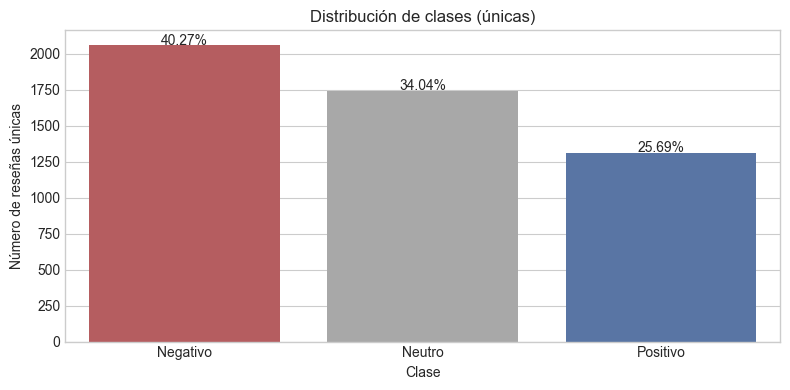

In [19]:
# Dejamos solo los registros únicos
df_unicos = df_nlp.drop_duplicates(subset="review").copy()

# Volvemos a graficar la distribución de las clases
clases_unicos = df_unicos["clase"].value_counts(dropna=False).reset_index()
clases_unicos.columns = ["clase", "n"]
clases_unicos["pct"] = 100 * clases_unicos["n"] / clases_unicos["n"].sum()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=clases_unicos, x="clase", y="n", palette=[colores_eda.get(c, "#888") for c in clases_unicos["clase"]], ax=ax)
ax.set_title("Distribución de clases (únicas)")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de reseñas únicas")
for i, row in clases_unicos.iterrows():
    ax.text(i, row["n"] + 5, f'{row["pct"]:.2f}%', ha="center", fontsize=10)
plt.tight_layout()
plt.show()

### Tabla de conteos en `df_unicos`

**Objetivo:** imprimir frecuencias y porcentajes por clase tras quitar duplicados, para documentar el desbalance o balance observado.

In [20]:
# Contamos cuántos registros hay por cada clase en df_unicos
conteo_clases_unicos = df_unicos["clase"].value_counts(dropna=False).reset_index()
conteo_clases_unicos.columns = ["clase", "n"]
conteo_clases_unicos["pct"] = 100 * conteo_clases_unicos["n"] / conteo_clases_unicos["n"].sum()
print(conteo_clases_unicos)

      clase     n        pct
0  Negativo  2058  40.266093
1    Neutro  1740  34.044218
2  Positivo  1313  25.689689


### Unicidad en `df_resenas` (sin balancear)

**Objetivo:** medir cuántas reseñas únicas hay en el dataset concatenado original `df_resenas` (todas las fuentes).

In [21]:
# Contar reseñas únicas en el dataset concatenado `df_resenas` (sin deduplicar aún).
num_unicos_resenas = df_resenas["review"].nunique()
print(f"Número de registros únicos en df_resenas: {num_unicos_resenas}")

Número de registros únicos en df_resenas: 13340


### `df_resenas_unicos`

**Objetivo:** crear un conjunto sin duplicados por `review` a partir de `df_resenas` para cruzar con el pipeline balanceado.

In [22]:
# Creamos un dataset con los registros únicos de df_resenas a partir de la columna "review"
df_resenas_unicos = df_resenas.drop_duplicates(subset="review").copy()
print(f"Shape del nuevo dataset único de reseñas: {df_resenas_unicos.shape}")

Shape del nuevo dataset único de reseñas: (13340, 2)


### Muestra de `df_resenas_unicos`

**Objetivo:** inspeccionar las primeras filas del dataset único no balanceado.

In [23]:
# Primeras filas de `df_resenas_unicos` para inspección rápida.
df_resenas_unicos.head(10)


,review,sentimiento
0,Un hotel muy bueno. El personal fue muy amabl...,1
1,"Muy buen hotel al nivel de lo esperado, habita...",1
2,Magnífico hotel. La verdad es que todo perfect...,1
3,"Hotel hermoso, buen diseño, original, limpio. ...",1
4,Magnífica ubicación en pleno centro de Sevilla...,1
5,Si estás buscando un hotel para alojarte en el...,1
6,Gran ubicación y una enorme comodidad. La cama...,1
7,"Precioso hotel en pleno centro de Sevilla, ent...",1
8,"Como todos los hoteles de la cadena, un 10. Ha...",1
9,Empiezo por lo menos agradable: no es posible ...,1


### Imputación de sentimiento faltante

**Objetivo:** tratar los NaN en `sentimiento` como clase 3 (neutro) en `df_resenas_unicos` para análisis posteriores.

In [24]:
# Tomamos los NaN como clase 3
df_resenas_unicos["sentimiento"] = df_resenas_unicos["sentimiento"].fillna(3)

### Distribución de clases en `df_resenas_unicos`

**Objetivo:** tabular y graficar la frecuencia de cada etiqueta numérica en el conjunto único no balanceado.

   clase     n        pct
0      1  9542  71.529235
1      0  2058  15.427286
2      3  1740  13.043478


C:\Users\rchic\AppData\Local\Temp\ipykernel_12856\153014530.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


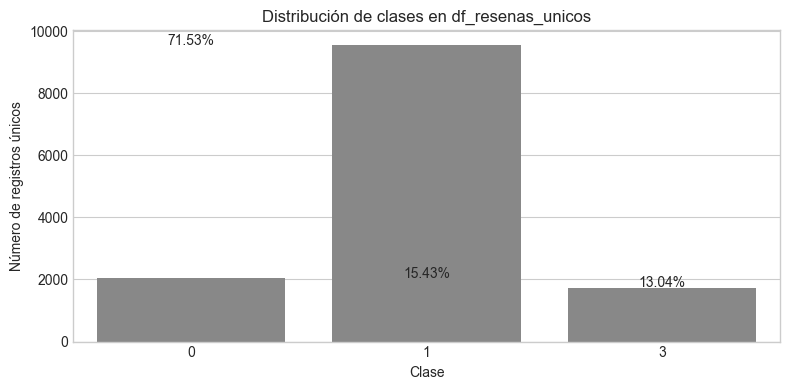

In [25]:

# Contamos cuántos registros hay por cada clase
clases_resenas_unicos = df_resenas_unicos["sentimiento"].value_counts(dropna=False).reset_index()
clases_resenas_unicos.columns = ["clase", "n"]
clases_resenas_unicos["pct"] = 100 * clases_resenas_unicos["n"] / clases_resenas_unicos["n"].sum()

print(clases_resenas_unicos)

# Graficamos la distribución de las clases en df_resenas_unicos
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=clases_resenas_unicos,
    x="clase",
    y="n",
    palette=[colores_eda.get(c, "#888") for c in clases_resenas_unicos["clase"]],
    ax=ax
)
ax.set_title("Distribución de clases en df_resenas_unicos")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de registros únicos")
for i, row in clases_resenas_unicos.iterrows():
    ax.text(i, row["n"] + 5, f'{row["pct"]:.2f}%', ha="center", fontsize=10)
plt.tight_layout()
plt.show()






### Balanceo Negativo / Positivo en `df_unicos`

**Objetivo:** incorporar hasta 745 reseñas positivas adicionales desde `df_resenas_unicos` que no estén ya en `df_unicos`, hasta igualar el conteo de Negativo y Positivo (con tope y semilla fija).

In [26]:
# Añadir reseñas de clase 1 (positivo) desde df_resenas_unicos que no estén en df_unicos,
# hasta equilibrar el conteo entre clase 0 (Negativo) y clase 1 (Positivo).
# Máximo 745 filas (o las que falten para balancear, si son menos).

reviews_en_unicos = set(df_unicos["review"])

# Candidatos: sentimiento 1 en df_resenas_unicos y texto aún no presente en df_unicos
s1 = df_resenas_unicos["sentimiento"]
mask_clase1 = (s1 == 1) | (s1 == 1.0)
candidatos = df_resenas_unicos[mask_clase1 & ~df_resenas_unicos["review"].isin(reviews_en_unicos)].copy()

n_neg = (df_unicos["clase"] == "Negativo").sum()
n_pos = (df_unicos["clase"] == "Positivo").sum()
faltan_positivos = max(0, int(n_neg - n_pos))

n_take = min(745, len(candidatos), faltan_positivos)

print(f"Negativos en df_unicos: {n_neg}, Positivos: {n_pos}")
print(f"Positivos a añadir para igualar a negativos: {faltan_positivos}")
print(f"Candidatos (clase 1, no en df_unicos): {len(candidatos)}")
print(f"Filas a incorporar (máx. 745): {n_take}")

if n_take == 0:
    print("No se añade nada (ya balanceado o sin candidatos).")
else:
    extra = candidatos.sample(n=n_take, random_state=42)
    # Valor de sentimiento como en df_unicos (texto 'positivo' típico del pipeline balanceado)
    ref_pos = df_unicos.loc[df_unicos["clase"] == "Positivo", "sentimiento"]
    sent_pos = ref_pos.iloc[0] if len(ref_pos) else "positivo"
    nuevas = pd.DataFrame({
        "review": extra["review"].values,
        "sentimiento": sent_pos,
        "clase": "Positivo",
        "len_review": extra["review"].fillna("").str.len().values,
    })
    # Misma estructura que df_unicos (columnas extra si las hay)
    for c in df_unicos.columns:
        if c not in nuevas.columns:
            nuevas[c] = np.nan
    nuevas = nuevas[df_unicos.columns]
    df_unicos = pd.concat([df_unicos, nuevas], ignore_index=True)

    n_neg2 = (df_unicos["clase"] == "Negativo").sum()
    n_pos2 = (df_unicos["clase"] == "Positivo").sum()
    print(f"Tras la unión — Negativos: {n_neg2}, Positivos: {n_pos2}")
    if n_neg2 != n_pos2:
        print("Aviso: 0/1 (Negativo/Positivo) aún no coinciden (p. ej. límite 745 o pocos candidatos).")


Negativos en df_unicos: 2058, Positivos: 1313
Positivos a añadir para igualar a negativos: 745
Candidatos (clase 1, no en df_unicos): 8229
Filas a incorporar (máx. 745): 745
Tras la unión — Negativos: 2058, Positivos: 2058


### Dimensiones de `df_unicos`

**Objetivo:** comprobar el tamaño del dataset tras el balanceo (filas y columnas).

In [27]:
# Dimensiones (filas, columnas) de `df_unicos` tras el balanceo Negativo/Positivo.
df_unicos.shape

(5856, 5)

### Imputación en `df_unicos`

**Objetivo:** asignar sentimiento 3 donde falte etiqueta en `df_unicos` antes de exportar o modelar.

In [28]:
# Imputar `sentimiento` faltante con 3 (neutro) en `df_unicos`.
df_unicos["sentimiento"] = df_unicos["sentimiento"].fillna(3)

### Distribución de clases tras imputación

**Objetivo:** visualizar de nuevo las clases en `df_unicos` con un gráfico de barras.

C:\Users\rchic\AppData\Local\Temp\ipykernel_12856\963953138.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clase_counts, x="clase", y="n", palette="viridis")


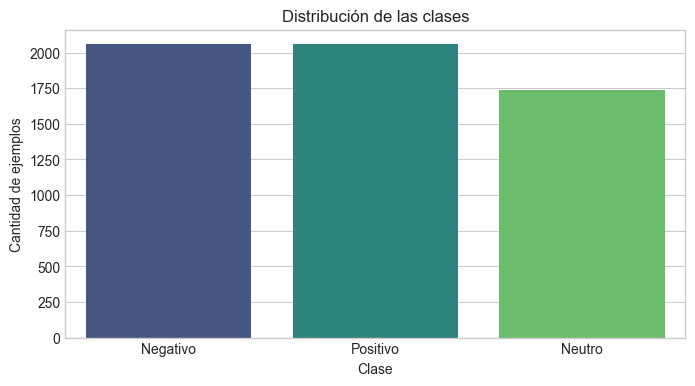

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contamos la cantidad de ejemplos por clase
clase_counts = df_unicos["clase"].value_counts().reset_index()
clase_counts.columns = ["clase", "n"]

plt.figure(figsize=(8, 4))
sns.barplot(data=clase_counts, x="clase", y="n", palette="viridis")
plt.title("Distribución de las clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad de ejemplos")
plt.show()

### Duplicados de fila completos

**Objetivo:** contar si existen filas totalmente duplicadas en `df_unicos` (no solo el texto).

In [30]:
# Contamos los registros duplicados
num_duplicados = df_unicos.duplicated().sum()
print(f"Número de registros duplicados: {num_duplicados}")

Número de registros duplicados: 0


### Subconjunto `review` + `sentimiento`

**Objetivo:** preparar `df_review_sent` solo con las columnas necesarias para exportación y detección de idioma.

In [31]:
# Hacemos un dataset solo con review y sentimiento
df_review_sent = df_unicos[["review", "sentimiento"]].copy()
df_review_sent.head()

,review,sentimiento
0,El fin de semana mi pareja y yo hicimos una re...,negativo
1,"El hotel en general está bien, las habtiacione...",neutro
2,"El hotel es moderno, amplio y limpio, pero no ...",neutro
3,Calefacción averiada o no operativa. Se coment...,negativo
4,Este hotel ha bajado notoriamente su categoria...,negativo


### Exportación a CSV

**Objetivo:** guardar el dataset unificado de reseñas y sentimientos en `datasetUnificadoReviewsHoteles.csv` para uso fuera del notebook.

In [32]:
# Exportar `df_review_sent` a CSV para uso externo o en otros notebooks.
df_review_sent.to_csv("datasetUnificadoReviewsHoteles.csv", index=False)

### Detección de idioma (`langdetect`)

**Objetivo:** añadir la columna `idioma` a cada reseña y mostrar el conteo de registros por código de idioma.

In [33]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0  # Para resultados reproducibles

# Detectar el idioma de cada review (esto puede tardar un poco)
def detectar_idioma(texto):
    try:
        return detect(str(texto))
    except:
        return "unk"

df_review_sent["idioma"] = df_review_sent["review"].apply(detectar_idioma)

# Contar el número de registros por idioma
conteo_idiomas = df_review_sent["idioma"].value_counts()
print("Cantidad de registros por idioma:")
print(conteo_idiomas)

Cantidad de registros por idioma:
idioma
es    5812
en      21
fr      10
it       7
nl       2
tr       2
pt       1
de       1
Name: count, dtype: int64


### Sentimiento en reseñas no españolas

**Objetivo:** analizar qué etiquetas de `sentimiento` tienen las filas cuyo idioma detectado no es `es`.

In [34]:
# Contamos de los reviews que NO están en español ("es") de qué etiquetas (sentimientos) son
no_espanol = df_review_sent[df_review_sent["idioma"] != "es"]
conteo_tags_no_es = no_espanol["sentimiento"].value_counts()
print("Cantidad de etiquetas en reviews en otro idioma:")
print(conteo_tags_no_es)

Cantidad de etiquetas en reviews en otro idioma:
sentimiento
negativo    18
positivo    15
neutro      11
Name: count, dtype: int64


#Agregamos un nuevo dataset de reseñas del hotel de cali

## Dataset adicional: reseñas hotel Cali

**Objetivo:** cargar `resenas_hotel.csv` y conocer sus dimensiones.

In [35]:
# Carga con separador ;
df_resenas_cali = pd.read_csv(CARPETA_DATOS / "resenas_hotel.csv", sep=",", encoding="utf-8")
print("=== RESEÑAS ===")
print(f"Dimensiones: {df_resenas_cali.shape[0]} filas, {df_resenas_cali.shape[1]} columnas")

=== RESEÑAS ===
Dimensiones: 5500 filas, 8 columnas


### Exploración inicial de reseñas Cali

**Objetivo:** revisar tipos de datos y una muestra de filas del CSV de Cali.

In [36]:
# Info y tipos
df_resenas_cali.info()
df_resenas_cali.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_Reserva           5500 non-null   int64 
 1   Sexo                 5500 non-null   object
 2   Tipo_Habitacion      5500 non-null   object
 3   Motivo_Viaje         5500 non-null   object
 4   Comentario_Positivo  4141 non-null   object
 5   Comentario_Negativo  3806 non-null   object
 6   Reseña_Completa      5500 non-null   object
 7   Rating               5500 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 343.9+ KB


,ID_Reserva,Sexo,Tipo_Habitacion,Motivo_Viaje,Comentario_Positivo,Comentario_Negativo,Reseña_Completa,Rating
0,84810,M,Doble (1 cama),DEPORTIVO,la habitacion eStaba limpia,NaN,La habitacion rstaba limpiia.,4
1,15592,M,Doble (1 cama),DEPORTIVO,el personal fue muy amable,falta mantenimiento en algunas areas,El personal fue muy amable. sin embargo falta ...,4
2,4278,F,Doble Twin (2 camas),TURISMO,la piscina estaba muy bien,habiA olor raro enla habitacion,"La piscina estaba muy bien, la verdad habiA ol...",3
3,98196,F,Cuádruple,OTRO,las camas eran comodas,se escuchaba todo del pasillo,Las camas eran comodas. eso sí se escuchaba to...,3
4,37048,M,Triple,SALUD,todo estuvo bien en generral,NaN,Todo estuvo bien en generral. Volvería.,4
5,33098,F,Sencilla,NEGOCIO,NaN,NaN,estuvo ok,2
6,30256,M,Sencilla,NEGOCIO,el wifi funcionaba bien,habia humedad en el cuarto,El wifi funcionaba bien. igual habia humedad e...,2
7,19289,M,Doble (1 cama),DEPORTIVO,la habitación estaba limpia,NaN,La habitación estaba limpia. Lo recomiendo.,4
8,97530,M,Doble Twin (2 camas),NEGOCIO,buena relacion calidad preCio,los muebles estaban algo deteriorados,Buena relacion calidad precio. Los muebles est...,3
9,14434,F,Sencilla,OTRO,todo estuvo bien en general,la comida llego fria,"Todo estuvo bien en general, la verdad la comi...",4


### Estadísticas y cardinalidad

**Objetivo:** obtener `describe` numérico y el número de valores únicos por columna para perfilar el dataset.

In [37]:
# Estadísticas descriptivas (numéricas) y valores únicos en categóricas
print("Describe (numérico):")
display(df_resenas_cali.describe(include=[np.number]))
print("\nValores únicos por columna:")
for col in df_resenas_cali.columns:
    print(f"  {col}: {df_resenas_cali[col].nunique()} únicos")

Describe (numérico):


,ID_Reserva,Rating
count,5500.000000,5500.000000
mean,51179.593455,3.418364
std,28519.931634,0.981401
min,1022.000000,1.000000
25%,26439.750000,3.000000
50%,51199.500000,3.000000
75%,76018.500000,4.000000
max,99994.000000,5.000000



Valores únicos por columna:
  ID_Reserva: 5500 únicos
  Sexo: 2 únicos
  Tipo_Habitacion: 6 únicos
  Motivo_Viaje: 6 únicos
  Comentario_Positivo: 709 únicos
  Comentario_Negativo: 821 únicos
  Reseña_Completa: 3931 únicos
  Rating: 5 únicos


### Disponibilidad de comentarios positivo / negativo

**Objetivo:** contar filas con `Comentario_Positivo`, con `Comentario_Negativo` y casos solo con `Reseña_Completa` sin comentarios parciales.

In [38]:
# Contar registros con comentario positivo
n_positivo = df_resenas_cali['Comentario_Positivo'].notna().sum()
# Contar registros con comentario negativo
n_negativo = df_resenas_cali['Comentario_Negativo'].notna().sum()
# Contar registros que NO tienen ni comentario positivo NI negativo PERO sí tienen reseña completa
n_solo_resena = df_resenas_cali[
    df_resenas_cali['Comentario_Positivo'].isna() &
    df_resenas_cali['Comentario_Negativo'].isna() &
    df_resenas_cali['Reseña_Completa'].notna()
].shape[0]

print(f"Registros con Comentario_Positivo: {n_positivo}")
print(f"Registros con Comentario_Negativo: {n_negativo}")
print(f"Registros SIN positivo/negativo pero CON Reseña_Completa: {n_solo_resena}")

Registros con Comentario_Positivo: 4141
Registros con Comentario_Negativo: 3806
Registros SIN positivo/negativo pero CON Reseña_Completa: 362


### Longitud de texto (caracteres) por campo

**Objetivo:** resumir longitud en caracteres de comentarios positivos, negativos y reseña completa (útil para NLP).

In [39]:
# Longitud de texto en comentarios (para análisis NLP)
text_cols = ["Comentario_Positivo", "Comentario_Negativo", "Reseña_Completa"]
for col in text_cols:
    if col in df_resenas_cali.columns:
        lengths = df_resenas_cali[col].fillna("").str.len()
        print(f"{col}: media={lengths.mean():.0f}, mediana={lengths.median():.0f}, min={lengths.min()}, max={lengths.max()}")

Comentario_Positivo: media=21, mediana=25, min=0, max=44
Comentario_Negativo: media=24, mediana=26, min=0, max=101
Reseña_Completa: media=56, mediana=57, min=9, max=150


### Histograma de longitud de reseña completa

**Objetivo:** visualizar la distribución de longitudes de `Reseña_Completa` en caracteres.

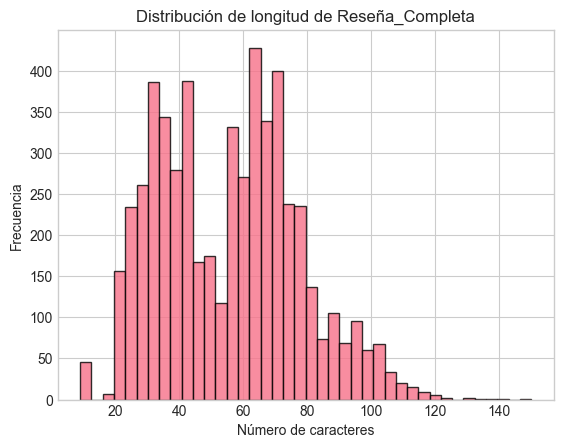

In [40]:
# Longitud de reseña completa (histograma)
df_resenas_cali["len_resena"] = df_resenas_cali["Reseña_Completa"].fillna("").str.len()
df_resenas_cali["len_resena"].hist(bins=40, edgecolor="black", alpha=0.8)
plt.title("Distribución de longitud de Reseña_Completa")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.show()

### Conteo de reseñas completas

**Objetivo:** cuántos registros tienen `Reseña_Completa` no nula.

In [41]:
# Contar registros con `Reseña_Completa` no nula en el dataset de Cali.
num_resenas_completas = df_resenas_cali["Reseña_Completa"].notna().sum()
print(f"Número de registros con reseña completa: {num_resenas_completas}")

Número de registros con reseña completa: 5500


### Registros solo con reseña completa

**Objetivo:** aislar y mostrar ejemplos donde no hay comentario positivo ni negativo pero sí texto en `Reseña_Completa`.

In [42]:
# Filtramos registros que NO tienen comentario positivo NI negativo, pero SI tienen reseña completa
filtro_solo_resena = (
    df_resenas_cali["Reseña_Completa"].notna() &
    df_resenas_cali["Comentario_Positivo"].isna() &
    df_resenas_cali["Comentario_Negativo"].isna()
)

solo_resena = df_resenas_cali[filtro_solo_resena]
print("10 registros que no tienen comentario positivo o negativo pero sí reseña completa:")
display(solo_resena.head(10))

10 registros que no tienen comentario positivo o negativo pero sí reseña completa:


,ID_Reserva,Sexo,Tipo_Habitacion,Motivo_Viaje,Comentario_Positivo,Comentario_Negativo,Reseña_Completa,Rating,len_resena
5,33098,F,Sencilla,NEGOCIO,NaN,NaN,estuvo ok,2,9
11,98080,M,Doble (1 cama),NEGOCIO,NaN,NaN,no tengo mucho que decir.,5,25
18,13280,F,Sencilla,SALUD,NaN,NaN,esperaba mas la verdad.,4,23
29,72426,F,Doble (1 cama),PERSONAL,NaN,NaN,esperaba mas la verdad.,2,23
35,1851,M,Doble Twin (2 camas),DEPORTIVO,NaN,NaN,no tengo mucho que decir.,5,25
43,45118,M,Sencilla,PERSONAL,NaN,NaN,esperaba mas la verdad.,4,23
54,61217,M,Doble Twin (2 camas),DEPORTIVO,NaN,NaN,fue una experiencia del monton.,4,31
61,83397,M,Suite,DEPORTIVO,NaN,NaN,fue una experiencia deel monton.,4,32
80,22319,F,Doble (1 cama),TURISMO,NaN,NaN,"regular, ni muy bien ni muy mal.",3,32
89,10358,M,Doble Twin (2 camas),PERSONAL,NaN,NaN,nada especial la verdad.,4,24


### Duplicados en `Reseña_Completa`

**Objetivo:** detectar textos de reseña completa repetidos y mostrar ejemplos si aplica.

In [43]:
# Revisamos si hay reseñas duplicadas

duplicadas = df_resenas_cali[df_resenas_cali.duplicated(subset=["Reseña_Completa"], keep=False) & df_resenas_cali["Reseña_Completa"].notna()]
print(f"Número de reseñas completas duplicadas: {duplicadas.shape[0]}")
if not duplicadas.empty:
    print("Ejemplo de reseñas duplicadas:")
    display(duplicadas[["ID_Reserva", "Reseña_Completa"]].head(10))
else:
    print("No se encontraron reseñas completas duplicadas.")

Número de reseñas completas duplicadas: 1986
Ejemplo de reseñas duplicadas:


,ID_Reserva,Reseña_Completa
5,33098,estuvo ok
7,19289,La habitación estaba limpia. Lo recomiendo.
10,89696,Habia mucho ruido en la noche.
11,98080,no tengo mucho que decir.
16,5165,Honestamente La tv no funcionaba bien.
18,13280,esperaba mas la verdad.
21,67237,No habia agua caliente en la mañana.
22,79907,El cuarto era amplio.
24,74563,El restaurante del hotel estuvo rico. Buen hotel.
28,92924,Buena experiencia en general lo recomiendo.


### Eliminación de duplicados por reseña completa

**Objetivo:** conservar una sola fila por `Reseña_Completa` duplicada (`keep='first'`) y reportar el nuevo tamaño.

In [44]:
# Eliminamos los registros que tienen 'Reseña_Completa' duplicada (dejando solo el primero)
df_resenas_cali = df_resenas_cali.drop_duplicates(subset=["Reseña_Completa"], keep="first")
print(f"Número de registros después de eliminar duplicados de reseñas completas: {len(df_resenas_cali)}")

Número de registros después de eliminar duplicados de reseñas completas: 3931


## El dataset tiene mas columnas que solo la review, como necesitamos review y sentimientos vamos a convertir las reseñas en ese formato
- SI la reseña tiene solo el comentario positivo tomamos reseña completa y asignamos sentimiento postivio
- SI la reseña tiene solo el comentario negativo tomamos reseña completa y asignamos sentimiento negativo
- SI la reseña tiene tanto el comentario postivo como negativo tomamos reseña completa y asignamos sentimiento neutral

### Derivación de `sentimiento` desde comentarios

**Objetivo:** construir `df_reseñas_sentimiento` con `review` y etiqueta inferida (positivo / negativo / neutro) según qué comentarios existan por fila.

In [ ]:
# Creamos un nuevo DataFrame con las columnas: review (la reseña completa) y sentimiento

def obtener_sentimiento(row):
    if pd.notna(row['Comentario_Positivo']) and pd.isna(row['Comentario_Negativo']):
        return 'positivo'
    elif pd.isna(row['Comentario_Positivo']) and pd.notna(row['Comentario_Negativo']):
        return 'negativo'
    elif pd.notna(row['Comentario_Positivo']) and pd.notna(row['Comentario_Negativo']):
        return 'neutro'
    else:
        # Si por algún motivo no hay comentario positivo ni negativo, podemos dejar como NaN
        return pd.NA

# Solo trabajamos sobre registros con Reseña_Completa no nula
df_reseñas_sentimiento = df_resenas_cali[df_resenas_cali["Reseña_Completa"].notna()].copy()
df_reseñas_sentimiento["sentimiento"] = df_reseñas_sentimiento.apply(obtener_sentimiento, axis=1)

# Dejamos solo las columnas requeridas
df_reseñas_sentimiento = df_reseñas_sentimiento[["Reseña_Completa", "sentimiento"]]
df_reseñas_sentimiento = df_reseñas_sentimiento.rename(columns={"Reseña_Completa": "review"})

print(df_reseñas_sentimiento.head(10))

                                              review sentimiento
0                      La habitacion rstaba limpiia.    positivo
1  El personal fue muy amable. sin embargo falta ...      neutro
2  La piscina estaba muy bien, la verdad habiA ol...      neutro
3  Las camas eran comodas. eso sí se escuchaba to...      neutro
4            Todo estuvo bien en generral. Volvería.    positivo
5                                          estuvo ok        <NA>
6  El wifi funcionaba bien. igual habia humedad e...      neutro
7        La habitación estaba limpia. Lo recomiendo.    positivo
8  Buena relacion calidad precio. Los muebles est...      neutro
9  Todo estuvo bien en general, la verdad la comi...      neutro


### Filtrado de filas sin etiqueta

**Objetivo:** quitar registros donde no se pudo asignar `sentimiento` tras las reglas definidas.

In [46]:
# Ahora eliminamos los registros que quedaron sin sentimiento
df_reseñas_sentimiento = df_reseñas_sentimiento[df_reseñas_sentimiento["sentimiento"].notna()]
print(f"Número de registros después de eliminar reseñas sin sentimiento: {len(df_reseñas_sentimiento)}")
print(df_reseñas_sentimiento.head(10))

Número de registros después de eliminar reseñas sin sentimiento: 3889
                                               review sentimiento
0                       La habitacion rstaba limpiia.    positivo
1   El personal fue muy amable. sin embargo falta ...      neutro
2   La piscina estaba muy bien, la verdad habiA ol...      neutro
3   Las camas eran comodas. eso sí se escuchaba to...      neutro
4             Todo estuvo bien en generral. Volvería.    positivo
6   El wifi funcionaba bien. igual habia humedad e...      neutro
7         La habitación estaba limpia. Lo recomiendo.    positivo
8   Buena relacion calidad precio. Los muebles est...      neutro
9   Todo estuvo bien en general, la verdad la comi...      neutro
10                     Habia mucho ruido en la noche.    negativo


### Balance de clases (Cali)

**Objetivo:** tabular y graficar la distribución de sentimientos en el subconjunto de Cali listo para unir.

      clase     n        pct
0    neutro  2752  70.763692
1  positivo   610  15.685266
2  negativo   527  13.551041


C:\Users\rchic\AppData\Local\Temp\ipykernel_12856\1115322242.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x="clase", y="n", palette="viridis")


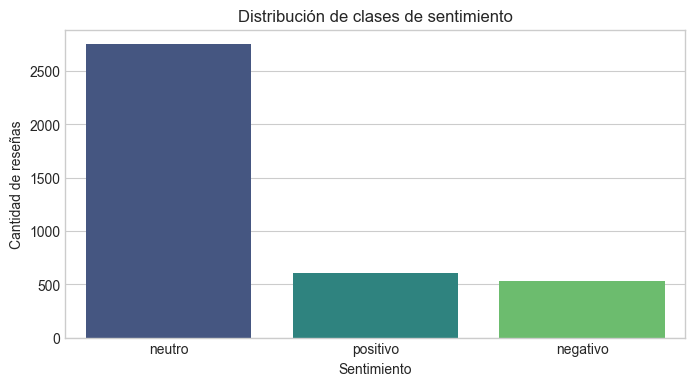

In [47]:
# Revisamos el balance de clases en la columna 'sentimiento'
import matplotlib.pyplot as plt
import seaborn as sns

class_counts = df_reseñas_sentimiento["sentimiento"].value_counts().reset_index()
class_counts.columns = ["clase", "n"]
class_counts["pct"] = 100 * class_counts["n"] / class_counts["n"].sum()
print(class_counts)

plt.figure(figsize=(8,4))
sns.barplot(data=class_counts, x="clase", y="n", palette="viridis")
plt.title("Distribución de clases de sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de reseñas")
plt.show()

## Unión Cali + dataset exportado

**Objetivo:** concatenar `df_review_sent` con las reseñas de Cali homogeneizando tipos en `sentimiento` y validar forma y conteos.

In [48]:
# Unificamos los dataframes df_review_sent y df_reseñas_sentimiento

# Primero, nos aseguramos de que ambos tengan las mismas columnas con los mismos nombres:
# df_review_sent: columnas = ["review", "sentimiento"]
# df_reseñas_sentimiento: columnas = ["review", "sentimiento"]

# En caso de que existan diferencias de tipo/categoría en la columna 'sentimiento', las homogeneizamos (opcional)
df_review_sent["sentimiento"] = df_review_sent["sentimiento"].astype(str)
df_reseñas_sentimiento["sentimiento"] = df_reseñas_sentimiento["sentimiento"].astype(str)

# Unificamos ambos dataframes usando concat
df_reviews_unificado = pd.concat([df_review_sent, df_reseñas_sentimiento], ignore_index=True)

# Mostramos un resumen rápido para validar la unión
print(f"Shape del dataframe unificado: {df_reviews_unificado.shape}")
print(df_reviews_unificado.head())
print(df_reviews_unificado["sentimiento"].value_counts())

Shape del dataframe unificado: (9745, 3)
                                              review sentimiento idioma
0  El fin de semana mi pareja y yo hicimos una re...    negativo     es
1  El hotel en general está bien, las habtiacione...      neutro     es
2  El hotel es moderno, amplio y limpio, pero no ...      neutro     es
3  Calefacción averiada o no operativa. Se coment...    negativo     es
4  Este hotel ha bajado notoriamente su categoria...    negativo     es
sentimiento
neutro      4492
positivo    2668
negativo    2585
Name: count, dtype: int64


### Distribución tras unificar

**Objetivo:** medir y graficar la distribución de clases en `df_reviews_unificado`.

      clase     n        pct
0    neutro  4492  46.095434
1  positivo  2668  27.378143
2  negativo  2585  26.526424


C:\Users\rchic\AppData\Local\Temp\ipykernel_12856\3531809469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clase_counts, x="clase", y="n", palette="viridis")


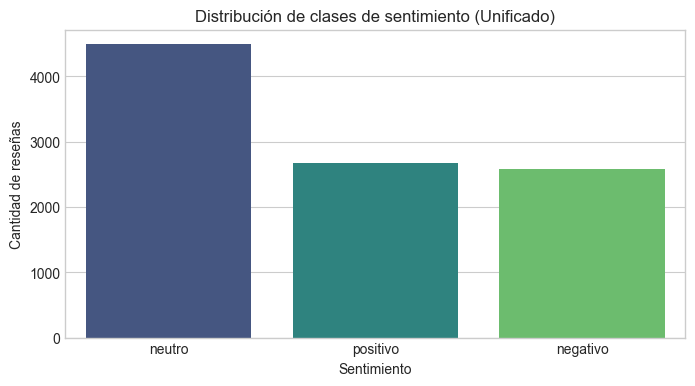

In [49]:
# Revisamos la distribución de las clases después de la unificación
clase_counts = df_reviews_unificado["sentimiento"].value_counts().reset_index()
clase_counts.columns = ["clase", "n"]
clase_counts["pct"] = 100 * clase_counts["n"] / clase_counts["n"].sum()
print(clase_counts)

plt.figure(figsize=(8,4))
sns.barplot(data=clase_counts, x="clase", y="n", palette="viridis")
plt.title("Distribución de clases de sentimiento (Unificado)")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de reseñas")
plt.show()

### Vista del dataframe unificado

**Objetivo:** inspeccionar el objeto `df_reviews_unificado` completo o su representación.

In [50]:
# Inspeccionar el contenido del `DataFrame` unificado (Cali + reseñas previas).
df_reviews_unificado

,review,sentimiento,idioma
0,El fin de semana mi pareja y yo hicimos una re...,negativo,es
1,"El hotel en general está bien, las habtiacione...",neutro,es
2,"El hotel es moderno, amplio y limpio, pero no ...",neutro,es
3,Calefacción averiada o no operativa. Se coment...,negativo,es
4,Este hotel ha bajado notoriamente su categoria...,negativo,es
...,...,...,...
9740,Pero la cama no era muy comoda. Me gusto el se...,neutro,NaN
9741,"Muy bien ubicado cerca al centro, igual el col...",neutro,NaN
9742,Las camas eran comodas. sin embargo el persona...,neutro,NaN
9743,Buen servicio dehabitaciones. Volvería.,positivo,NaN


### Idioma en el conjunto unificado

**Objetivo:** detectar idioma por fila en `df_reviews_unificado` con manejo de excepciones y añadir columna `idioma`.

In [51]:
# Volvemos a identificar el idioma del review

# Usamos langdetect para detectar el idioma. Si ya está importada no hará nada, si no, debe importarse antes.
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

def detectar_idioma(texto):
    try:
        return detect(str(texto))
    except LangDetectException:
        return None

# Aplicar la función a la columna 'review' del dataframe unificado
df_reviews_unificado["idioma"] = df_reviews_unificado["review"].apply(detectar_idioma)

# Mostramos una muestra para validar
print(df_reviews_unificado[["review", "idioma"]].head())


                                              review idioma
0  El fin de semana mi pareja y yo hicimos una re...     es
1  El hotel en general está bien, las habtiacione...     es
2  El hotel es moderno, amplio y limpio, pero no ...     es
3  Calefacción averiada o no operativa. Se coment...     es
4  Este hotel ha bajado notoriamente su categoria...     es


### Resumen por idioma

**Objetivo:** tabla de frecuencias de la columna `idioma` (incluyendo NaN si los hay).

In [52]:
# Mostramos cantidad de registros por idioma
conteo_idiomas = df_reviews_unificado["idioma"].value_counts(dropna=False).reset_index()
conteo_idiomas.columns = ["idioma", "cantidad"]
print(conteo_idiomas)

  idioma  cantidad
0     es      9675
1     en        21
2     nl        11
3     fr        11
4     it        10
5     pt        10
6     tr         2
7     ro         2
8     ca         2
9     de         1


In [54]:
# Exportamos el dataset final con las reseñas (con idioma)
df_reviews_unificado.to_csv("df_reviews_unificado_final.csv", index=False)

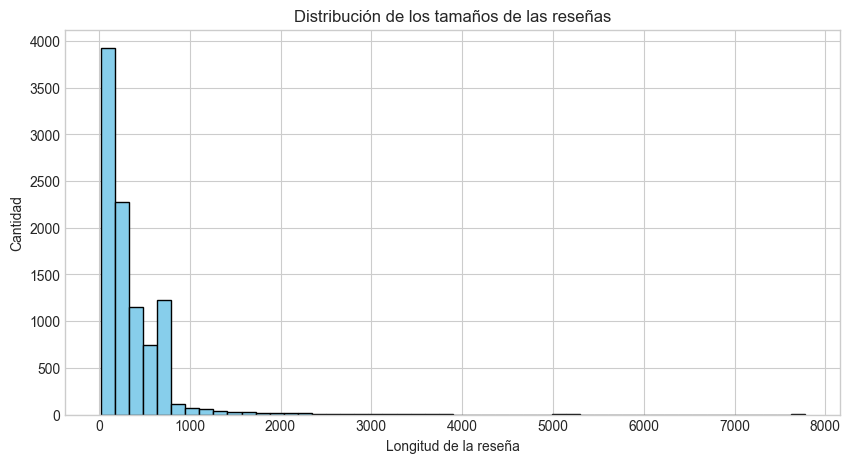

In [55]:
import matplotlib.pyplot as plt

# Creamos una columna con la longitud de cada review
df_reviews_unificado['len_review'] = df_reviews_unificado['review'].str.len()

# Graficamos la distribución de los tamaños de las reseñas
plt.figure(figsize=(10,5))
plt.hist(df_reviews_unificado['len_review'].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Longitud de la reseña')
plt.ylabel('Cantidad')
plt.title('Distribución de los tamaños de las reseñas')
plt.show()